# Symmetry-aware vs symmetry-unaware NQS — paper-styled comparison

Reproduces the look of **FIG. 2(a)** of Kufel et al. (the 2D paper) for our
**3D toric code** $L=2$ (OBC) validation runs: the symmetry-aware *combo* net
converges to the exact-diagonalization energy (black dash-dot) while the
symmetry-unaware *GeoCNN* baseline gets stuck above it. Different shades =
different network depth/width variants (our analogue of the paper's
"different random initializations and hyperparameters").

All knobs live in the **Config** cell — tweak and re-run the last cell.
Data source: the two `wandb_export_*.csv` in the repo root.

## Config — tweak these

In [3]:
import csv, glob, os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# locate the repo root (works whether the notebook is launched from repo root
# or a subdir) by walking up until we find the wandb exports
REPO = os.getcwd()
while not glob.glob(os.path.join(REPO, 'wandb_export_*.csv')) and REPO != '/':
    REPO = os.path.dirname(REPO)

# --- plot knobs ---
DENSITY   = False          # True -> plot energy density E/N (per-site), like the paper
N_QUBITS  = 12             # L=2 OBC has 12 edge qubits (only used if DENSITY)
YLIM      = (-14.283, -14.229)   # y-window: shows the tail of the descent + the gap
XLIM      = (0, 120)
SHOW_BANDS = True          # shade each run's seed min-max band
LINE_WIDTH = 1.5           # thickness of the run curves
EXACT_LW   = 2.0        # thickness of the exact dash-dot reference line
SAVE_TO   = os.path.join(REPO, 'figures', 'validation_paper_style.png')

# which runs are symmetry-aware (combo) vs symmetry-unaware (GeoCNN)
SYMM = ['cnn-4-4_8-8-1', 'cnn-8-8_4-4-1', 'cnn-8-8-8_4-4-1', 'cnn-4-4_8-8-8-1',
        'cnn-4-4_8-1', 'cnn-8_4-4-1', 'cnn-4-4_1']
NONS = ['geocnn-8-8-8', 'geocnn-8-8-8-4-4', 'geocnn-4-4-8-8-8-4']

# colour ramps: orange->brown for symmetric, purples for non-symmetric
ORANGE_RAMP = (0.45, 0.90)   # start,end sampled from YlOrBr
PURPLE_RAMP = (0.50, 0.85)   # ... from Purples
print('repo:', REPO)

repo: /Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main


## Load the wandb exports

In [4]:
def load_csv(path):
    with open(path) as fh:
        r = csv.reader(fh); cols = next(r); rows = list(r)
    d = {c: [] for c in cols}
    for row in rows:
        for c, v in zip(cols, row):
            d[c].append(float(v) if v not in ('', 'NaN') else np.nan)
    return {c: np.asarray(v) for c, v in d.items()}

def find(metric):
    """Return the wandb export that holds columns '<model> - <metric>'."""
    for p in sorted(glob.glob(os.path.join(REPO, 'wandb_export_*.csv'))):
        d = load_csv(p)
        if any(c.endswith(f' - {metric}') for c in d):
            return d
    raise FileNotFoundError(metric)

E = find('energy')     # <model> - energy  (+ __MIN/__MAX seed bands)
D = find('delta')      # <model> - delta   (relative error, for backing out E_exact)
print('loaded', len([c for c in E if c.endswith(' - energy')]), 'energy curves')

loaded 10 energy curves


## Plot style (paper-aligned)

Boxed thick axes, inward ticks — matching the paper figures. The axis-box
thickness is `axes.linewidth`; the tick thickness is `xtick/ytick.major.width`.
Edit `paper_style()` to restyle globally.

In [5]:
def paper_style():
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans'],
        'font.weight': 'normal',
        'mathtext.fontset': 'cm',
        'axes.linewidth': 1.8, 'axes.edgecolor': 'black',
        'axes.spines.top': True, 'axes.spines.right': True,
        'xtick.direction': 'in', 'ytick.direction': 'in',
        'xtick.major.size': 6, 'ytick.major.size': 6,
        'xtick.major.width': 1.6, 'ytick.major.width': 1.6,
        'xtick.labelsize': 15, 'ytick.labelsize': 15,
        'axes.labelsize': 19, 'figure.dpi': 130,
    })

paper_style()

## The comparison plot (two panels)

**(a)** energy vs training step and **(b)** log relative error $\delta=|E-E_0|/|E_0|$
vs step, side by side in the same style. The exact energy is backed out per run
from the converged tail ($E_0 = E/(1-\delta)$) and drawn as the black dash-dot
reference in (a) — no separate ED file needed. Panel (b)'s y-window is `DELTA_YLIM`
(local to this cell). Re-run this cell after changing any knob.

E0 = -14.2794 | saved -> /Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/figures/validation_paper_style.png


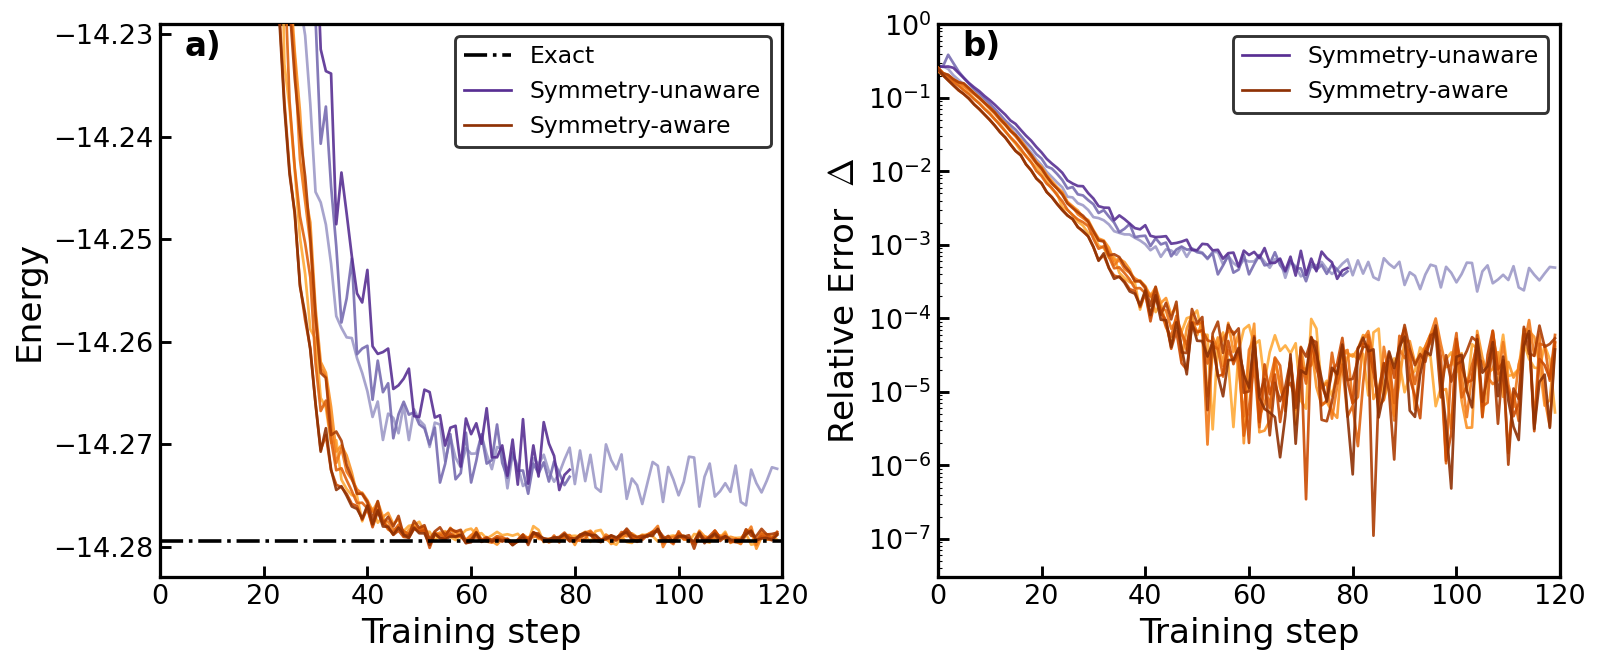

In [6]:
SCALE = (1.0 / N_QUBITS) if DENSITY else 1.0
DELTA_YLIM  = (3e-8, 1.0)    # y-window for the log-error panel (relative error δ)
DELTA_FLOOR = DELTA_YLIM[0]  # drop δ points at/below this (MCMC-noise dips that
                             # would otherwise spike to the axis floor); None keeps all

def series(model):
    """(step, E, lo, hi) for a run, scaled to density if requested."""
    s = E['Step']; e = E[f'{model} - energy']
    lo = E.get(f'{model} - energy__MIN'); hi = E.get(f'{model} - energy__MAX')
    m = np.isfinite(e)
    return (s[m], e[m] * SCALE,
            lo[m] * SCALE if lo is not None else None,
            hi[m] * SCALE if hi is not None else None)

def series_delta(model, floor=None):
    """(step, δ, lo, hi) — relative energy error |E-E0|/|E0| for a run.
    Points with δ <= floor are dropped so noise dips don't plunge to the floor."""
    s = D['Step']; d = D[f'{model} - delta']
    lo = D.get(f'{model} - delta__MIN'); hi = D.get(f'{model} - delta__MAX')
    m = np.isfinite(d) & (d > 0)
    if floor is not None:
        m &= (d > floor)
    return (s[m], d[m],
            lo[m] if lo is not None else None,
            hi[m] if hi is not None else None)

# back out the exact energy from the converged tails
ex = []
for model in SYMM + NONS:
    e = E[f'{model} - energy']; dd = D[f'{model} - delta']
    n = min(len(e), len(dd))
    tail = (e[:n] / (1 - dd[:n]))
    tail = tail[np.isfinite(tail)][-20:]
    if len(tail):
        ex.append(np.median(tail))
E0 = float(np.mean(ex)) * SCALE

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.2))
oranges = plt.cm.YlOrBr(np.linspace(*ORANGE_RAMP, len(SYMM)))
purples = plt.cm.Purples(np.linspace(*PURPLE_RAMP, len(NONS)))

# ---- panel (a): energy vs training step -------------------------------------
for model, c in zip(NONS, purples):
    s, e, lo, hi = series(model)
    ax.plot(s, e, color=c, lw=LINE_WIDTH, alpha=0.9, zorder=2)
    if SHOW_BANDS and lo is not None:
        ax.fill_between(s, lo, hi, color=c, alpha=0.18, lw=0, zorder=1)
for model, c in zip(SYMM, oranges):
    s, e, lo, hi = series(model)
    ax.plot(s, e, color=c, lw=LINE_WIDTH, alpha=0.9, zorder=3)
    if SHOW_BANDS and lo is not None:
        ax.fill_between(s, lo, hi, color=c, alpha=0.18, lw=0, zorder=1)
ax.axhline(E0, color='black', ls='-.', lw=EXACT_LW, zorder=5)
ax.set_ylim(*YLIM); ax.set_xlim(*XLIM)
ax.set_xlabel('Training step')
ax.set_ylabel(r'$E_{gs}$' if DENSITY else r'Energy')

# ---- panel (b): log relative error vs training step -------------------------
for model, c in zip(NONS, purples):
    s, d, lo, hi = series_delta(model, floor=DELTA_FLOOR)
    ax2.semilogy(s, d, color=c, lw=LINE_WIDTH, alpha=0.9, zorder=2)
    if SHOW_BANDS and lo is not None:
        ax2.fill_between(s, lo, hi, color=c, alpha=0.18, lw=0, zorder=1)
for model, c in zip(SYMM, oranges):
    s, d, lo, hi = series_delta(model, floor=DELTA_FLOOR)
    ax2.semilogy(s, d, color=c, lw=LINE_WIDTH, alpha=0.9, zorder=3)
    if SHOW_BANDS and lo is not None:
        ax2.fill_between(s, lo, hi, color=c, alpha=0.18, lw=0, zorder=1)
ax2.set_ylim(*DELTA_YLIM); ax2.set_xlim(*XLIM)
ax2.set_xlabel('Training step')
ax2.set_ylabel(r'Relative Error  $\Delta$')

# ---- panel labels (bold, top-left corner) -----------------------------------
for a, lab in [(ax, 'a)'), (ax2, 'b)')]:
    a.text(0.04, 0.99, lab, transform=a.transAxes, fontsize=18,
           fontweight='bold', va='top', ha='left')

# ---- rounded legends (same style) -------------------------------------------
h_full = [Line2D([], [], color='black', ls='-.', lw=EXACT_LW, label='Exact'),
          Line2D([], [], color=purples[-1], lw=LINE_WIDTH, label='Symmetry-unaware'),
          Line2D([], [], color=oranges[-1], lw=LINE_WIDTH, label='Symmetry-aware')]
for a, hs in [(ax, h_full), (ax2, h_full[1:])]:   # (b) has no exact line -> drop it
    leg = a.legend(handles=hs, loc='upper right', fontsize=13,
                   frameon=True, fancybox=True, edgecolor='black')
    leg.get_frame().set_linewidth(1.6)

fig.tight_layout()
os.makedirs(os.path.dirname(SAVE_TO), exist_ok=True)
fig.savefig(SAVE_TO, dpi=200, bbox_inches='tight')
print('E0 =', round(E0, 5), '| saved ->', SAVE_TO)
plt.show()

### Tweaking tips
- **Line thickness:** `LINE_WIDTH` (curves) and `EXACT_LW` (exact line); the axis
  box is `axes.linewidth` and ticks are `xtick/ytick.major.width` in `paper_style()`.
- **Colours:** change `ORANGE_RAMP` / `PURPLE_RAMP`, or swap the colormaps
  (`plt.cm.YlOrBr`, `plt.cm.copper`, `plt.cm.Purples`, ...).
- **Per-site energy:** set `DENSITY = True` and adjust `YLIM` (values become ~ E/12).
- **Zoom:** `YLIM` / `XLIM` frame how much of the descent vs. the final gap shows.
- **Add/remove runs:** edit the `SYMM` / `NONS` lists (names = wandb run labels).
- **x as training time $\gamma n$:** multiply `E['Step']` by the SR step size in `series`.

## Phase transition — 3D bosonic toric code (Figure 4)

**a)** the *finite-difference* derivative $dO_{\mathrm{FM}}/dh_z$ vs $h_z$ for $L=4,5,6$
(bulk placement); the transition $h_c(L)$ is the peak, located between grid points by a
3-point parabola (no sigmoid fit). **b)** finite-size extrapolation: $h_c(L)$ vs $1/L$
(dark-blue points with bootstrap error bars) fit to the linear form
$h_{\mathrm{peak}} = h_c + a/L$ (shown on the plot); the extrapolated $h_c(\infty)$ is the
**X** at $1/L=0$ ($\approx 0.23$; fitted value printed to the console), with the
QMC reference $\approx 0.20$ (dotted).

The collapsed run at $L=6,\,h_z=0.36$ is dropped before differentiating (`TRANS_EXCLUDE`).
Saves to `figures/transition.png`.

h_c(L): L=4:0.300, L=5:0.277, L=6:0.278
fit: h_c(L) = 0.227 + 0.284/L  ->  h_c(inf) = 0.227  | saved -> /Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/figures/transition.png


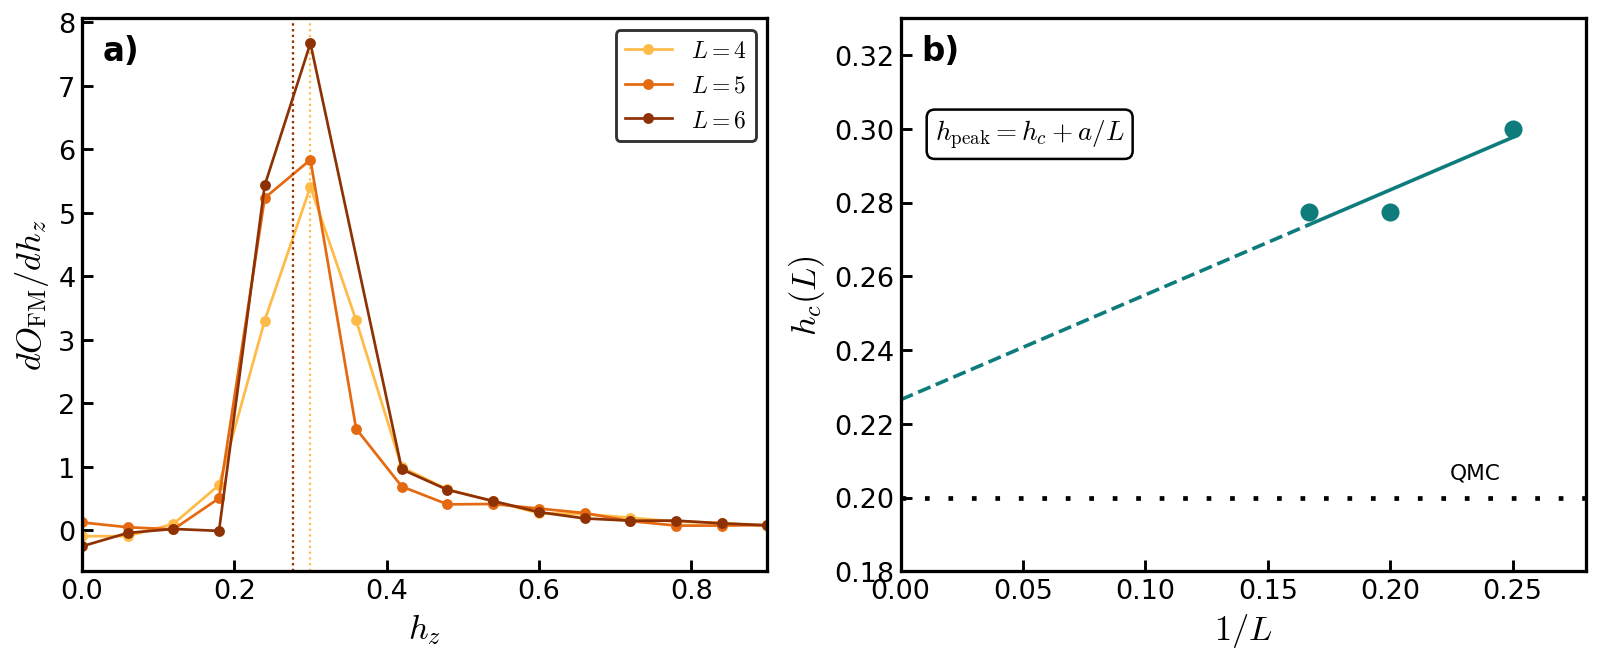

In [11]:
# =============================================================================
# Phase transition — 3D bosonic toric code (bulk placement, L = 4, 5, 6)
# a) finite-difference derivative dO_FM/dhz ;  b) 1/L finite-size extrapolation
# =============================================================================
import json
paper_style()

TRANS_DIR     = os.path.join(REPO, 'results', 'phase_hx0.2_bulk')
TRANS_EXCLUDE = {6: [0.36]}     # drop collapsed/untrusted runs before differentiating
L_RAMP        = (0.40, 0.90)    # YlOrBr sampling for the per-L curves
QMC_HC        = 0.20            # QMC reference (dotted line); None to hide
DOT_COLOR     = '#0e7c7b'       # teal for the h_c(L) points and fit line (complements panel a)
TRANS_SAVE    = os.path.join(REPO, 'figures', 'transition.png')

def load_fm(directory):
    recs = [json.load(open(p))
            for p in sorted(glob.glob(os.path.join(directory, 'fm_L*.json')))]
    if not recs:
        raise FileNotFoundError(directory)
    return sorted(recs, key=lambda r: r['L'])

def parabolic_peak(x, y):
    """Sub-grid location of the max of y(x) from a 3-point parabola around argmax
    (locates the derivative peak between grid points — no functional fit)."""
    i = int(np.argmax(y))
    if 0 < i < len(y) - 1:
        y0, y1, y2 = y[i-1], y[i], y[i+1]
        denom = y0 - 2*y1 + y2
        if denom != 0:
            return float(x[i] + 0.5 * (x[i+1] - x[i-1]) * 0.5 * (y0 - y2) / denom)
    return float(x[i])

recs = load_fm(TRANS_DIR)
Lc = plt.cm.YlOrBr(np.linspace(*L_RAMP, len(recs)))
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.2))

# ---- a) finite-difference derivative + peak per L ---------------------------
Ls, hcs = [], []
for r, c in zip(recs, Lc):
    L = r['L']
    hz = np.array(r['field']); O = np.array(r['O'])
    if L in TRANS_EXCLUDE:                                  # drop flagged points
        keep = ~np.any([np.isclose(hz, h) for h in TRANS_EXCLUDE[L]], axis=0)
        hz, O = hz[keep], O[keep]
    d = np.gradient(O, hz)                                  # finite-size derivative
    hc = float(np.clip(parabolic_peak(hz, d), hz.min(), hz.max()))
    Ls.append(L); hcs.append(hc)
    ax.plot(hz, d, '-o', color=c, lw=LINE_WIDTH, ms=5, label=f'$L={L}$')
    ax.axvline(hc, color=c, ls=':', lw=1.2)
ax.set_xlabel(r'$h_z$'); ax.set_ylabel(r'$dO_{\mathrm{FM}}/dh_z$')
ax.set_xlim(0, 0.9)

# ---- b) finite-size extrapolation h_c(L) vs 1/L -----------------------------
Ls = np.array(Ls, float); hcs = np.array(hcs)
x = 1.0 / Ls
m, b = np.polyfit(x, hcs, 1)                                # h_c(L) = h_c(inf) + a/L
xmin, xmax = x.min(), x.max()
xf = np.linspace(xmin, xmax, 20)                           # solid: through the points
xd = np.linspace(0.0, xmin, 20)                            # dashed: extrapolate to y-axis
ax2.plot(xf, b + m * xf, '-',  color=DOT_COLOR, lw=EXACT_LW, zorder=2)
ax2.plot(xd, b + m * xd, '--', color=DOT_COLOR, lw=EXACT_LW, zorder=2)
ax2.plot(x, hcs, 'o', color=DOT_COLOR, ms=9, zorder=3)
if QMC_HC is not None:
    ax2.axhline(QMC_HC, color='black', ls=(0, (1, 4)), lw=2.6, zorder=1)
    ax2.text(x.max() * 0.98, QMC_HC + 0.004, 'QMC',
             ha='right', va='bottom', fontsize=12)
ax2.set_xlabel(r'$1/L$'); ax2.set_ylabel(r'$h_c(L)$')
ax2.set_xlim(0, x.max() * 1.12); ax2.set_ylim(0.18, 0.33)
# mathematical form only (no fitted values)
ax2.text(0.05, 0.82, r'$h_{\mathrm{peak}} = h_c + a/L$',
         transform=ax2.transAxes, va='top', fontsize=15,
         bbox=dict(boxstyle='round', fc='white', ec='black', lw=1.4))

# ---- panel labels + rounded legend ------------------------------------------
for a, lab in [(ax, 'a)'), (ax2, 'b)')]:
    a.text(0.03, 0.97, lab, transform=a.transAxes, fontsize=18,
           fontweight='bold', va='top', ha='left')
leg = ax.legend(loc='upper right', fontsize=13, frameon=True,
                fancybox=True, edgecolor='black')
leg.get_frame().set_linewidth(1.6)

fig.tight_layout()
os.makedirs(os.path.dirname(TRANS_SAVE), exist_ok=True)
fig.savefig(TRANS_SAVE, dpi=200, bbox_inches='tight')
print('h_c(L): ' + ', '.join(f'L={int(L)}:{h:.3f}' for L, h in zip(Ls, hcs)))
print(f'fit: h_c(L) = {b:.3f} + {m:.3f}/L  ->  h_c(inf) = {b:.3f}  | saved -> {TRANS_SAVE}')
plt.show()